## setup

In [1]:
import pandas as pd 
import textdescriptives as td
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

# !python -m spacy download de_core_news_md
# nlp = spacy.load('de_core_news_md')  # 

In [ ]:
df_full = pd.read_parquet(r'/work/PENPAL/PENPAL_analysis/Berlin/Scripts & analyses/data/story_text_field_w_embeddings_jina.parquet')
df_full_de = df_full[df_full['language'] == 'de']

## compute surface metrics

In [9]:
td.get_valid_metrics()

{'all',
 'coherence',
 'dependency_distance',
 'descriptive_stats',
 'information_theory',
 'pos_proportions',
 'quality',
 'readability'}

In [4]:
def get_descriptive_metrics(df:pd.DataFrame, text_column:str, spacy_mdl:str="de_core_news_md", batch_size:int=5, n_process:int=5):
    '''
    Extract low level descriptive features doc_length, n_tokens, n_characters and n_sentences 
    '''
    # load nlp, add td to model
    print(f"[INFO:] Loading SpaCY model '{spacy_mdl}'...")
    nlp = spacy.load(spacy_mdl)
    nlp.add_pipe("textdescriptives/all") 

    # pass txt to pipeline
    text = df[text_column]
    print(f"[INFO:] Passing text from column '{text_column}' to pipeline ...")
    docs = nlp.pipe(text, batch_size=batch_size, n_process=n_process)

    print("[INFO:] Extracting metrics to df ...")
    metrics_df = td.extract_df(docs, include_text=True)

    # subset metrics to only include low level features, then concat
    # metrics_df = metrics_df[["doc_length", "n_tokens", "n_characters", "n_sentences"]]
    # final_df = pd.concat([df, metrics_df], axis=1)

    return metrics_df

In [5]:
df_metrics_user = get_descriptive_metrics(df=df_full_de, text_column='full_user')

[INFO:] Loading SpaCY model 'de_core_news_md'...
[INFO:] Passing text from column 'full_user' to pipeline ...
[INFO:] Extracting metrics to df ...


In [6]:
df_metrics_ai = get_descriptive_metrics(df=df_full_de, text_column='full_ai')

[INFO:] Loading SpaCY model 'de_core_news_md'...
[INFO:] Passing text from column 'full_ai' to pipeline ...
[INFO:] Extracting metrics to df ...


In [14]:
df_metrics_user.columns

Index(['text', 'passed_quality_check', 'n_stop_words', 'alpha_ratio',
       'mean_word_length', 'doc_length', 'symbol_to_word_ratio_#',
       'proportion_ellipsis', 'proportion_bullet_points',
       'contains_lorem ipsum', 'duplicate_line_chr_fraction',
       'duplicate_paragraph_chr_fraction', 'duplicate_ngram_chr_fraction_5',
       'duplicate_ngram_chr_fraction_6', 'duplicate_ngram_chr_fraction_7',
       'duplicate_ngram_chr_fraction_8', 'duplicate_ngram_chr_fraction_9',
       'duplicate_ngram_chr_fraction_10', 'top_ngram_chr_fraction_2',
       'top_ngram_chr_fraction_3', 'top_ngram_chr_fraction_4', 'oov_ratio',
       'dependency_distance_mean', 'dependency_distance_std',
       'prop_adjacent_dependency_relation_mean',
       'prop_adjacent_dependency_relation_std', 'entropy', 'perplexity',
       'per_word_perplexity', 'token_length_mean', 'token_length_median',
       'token_length_std', 'sentence_length_mean', 'sentence_length_median',
       'sentence_length_std', 'syll

In [7]:
df_metrics_ai['type'] = 'ai'
df_metrics_user['type'] = 'user'

In [8]:
df_metrics = pd.concat([df_metrics_ai, df_metrics_user])

In [35]:
df_long = df_metrics.melt(id_vars='type', value_vars=readability, var_name='metric', value_name='value')

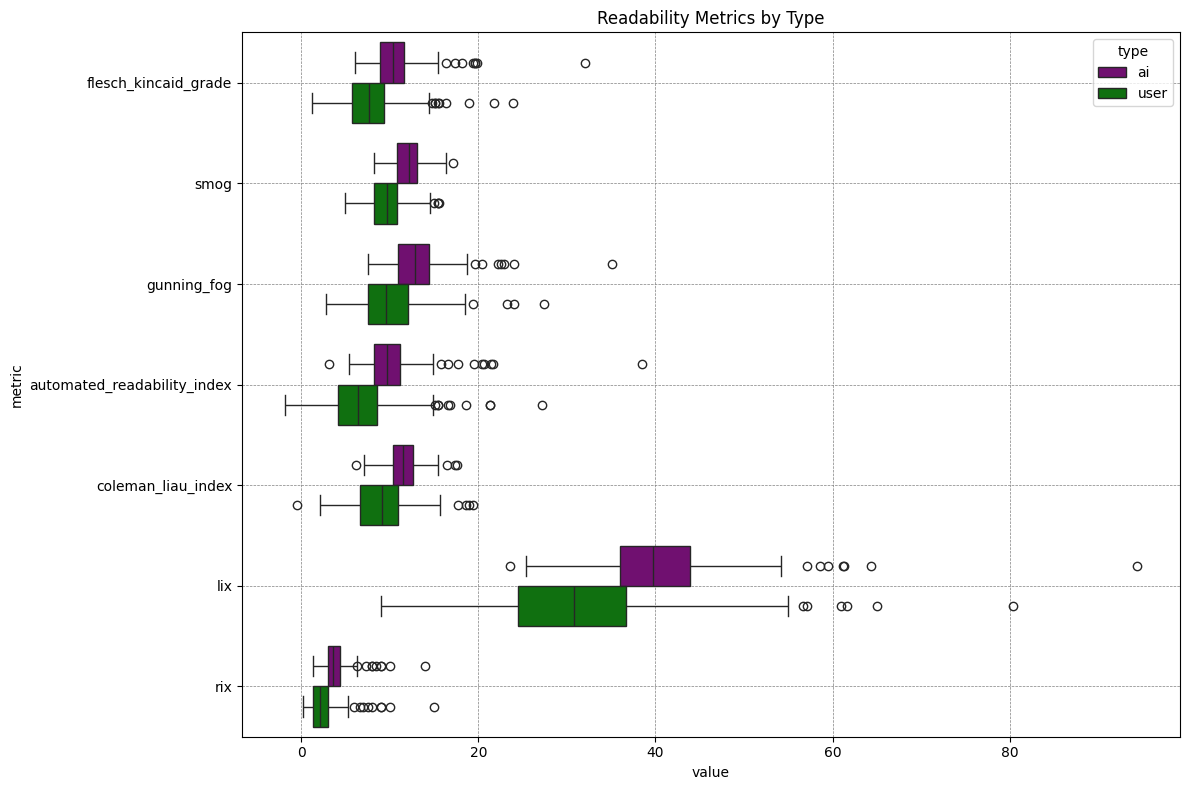

In [41]:
readability = ['flesch_kincaid_grade', 'smog',
       'gunning_fog', 'automated_readability_index', 'coleman_liau_index',
       'lix', 'rix']

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # readability metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Readability Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


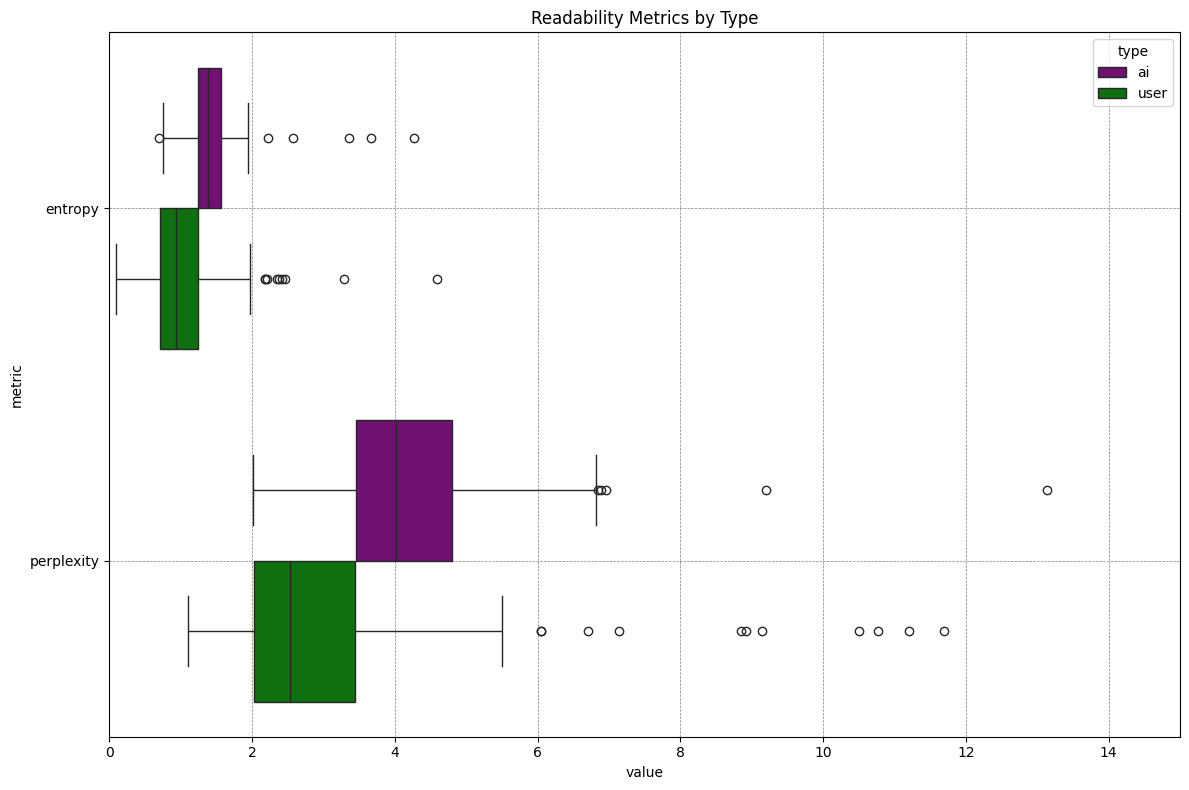

In [ ]:
complexity = ['entropy', 'perplexity']
df_long = df_metrics.melt(id_vars='type', value_vars=complexity, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)

cut_off = 15
plt.xlim((0, cut_off))
plt.title('Complexity Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


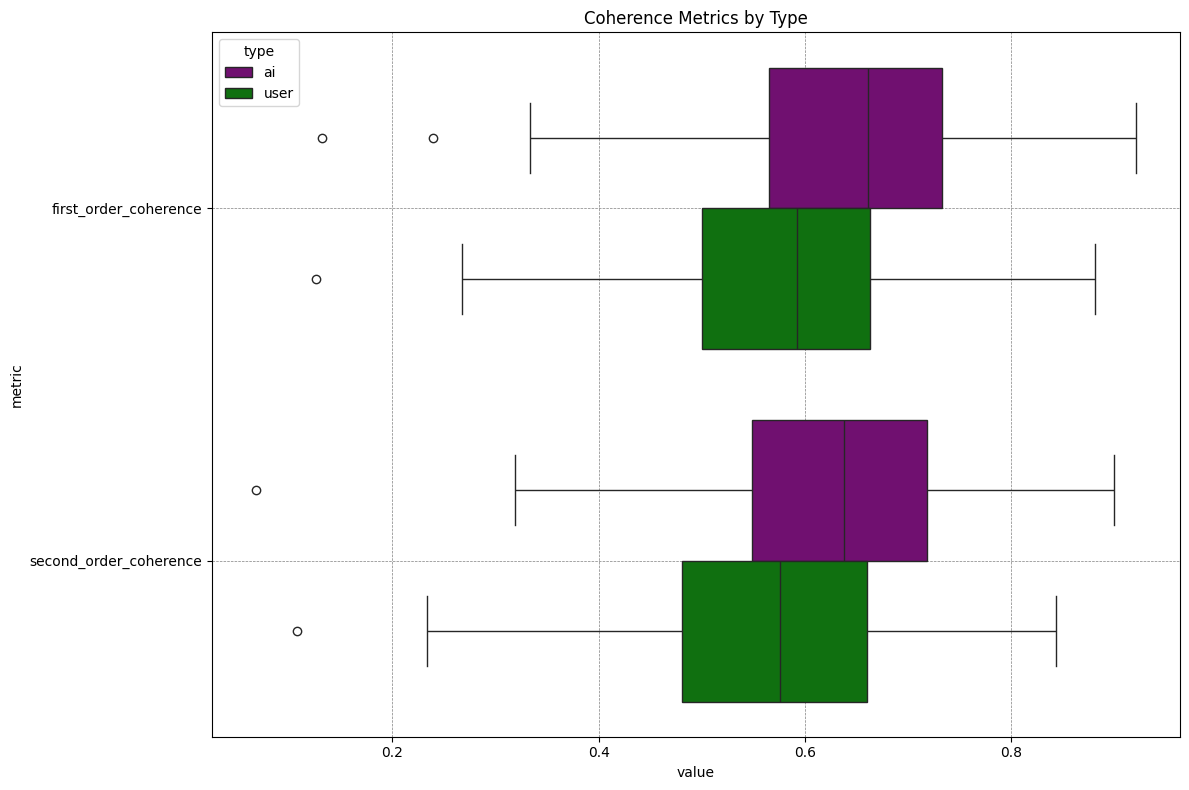

In [67]:
coherence = ['first_order_coherence', 'second_order_coherence']
df_long = df_metrics.melt(id_vars='type', value_vars=coherence, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Coherence Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()